# Análisis exploratorio de datos

Contentesta las siguientes preguntas escribiendo el código de Python necesario para encontrar las respuestas o producir las gráficas necesarias

---


In [1]:
# No mostrar advertencias
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar los datos
df = pd.read_csv('data/retailmax.csv')

# Mostrar las primeras filas
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
import sys, seaborn as sns
print(sys.executable)
print(sns.__version__)


/Library/Frameworks/Python.framework/Versions/3.10/bin/python3
0.13.2


### 1. ¿Cuál es la distribución de edades de los clientes?
- **Objetivo**: Comprender la distribución de las edades en el conjunto de datos.
- **Respuesta esperada**: Un histograma de la columna Age.

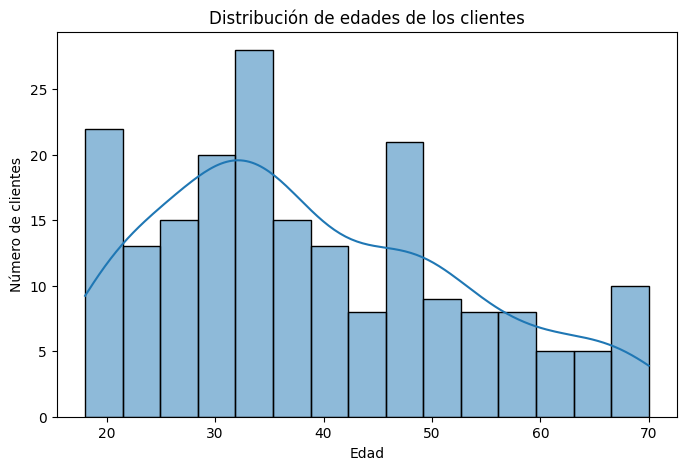

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=15, kde=True)

plt.title('Distribución de edades de los clientes')
plt.xlabel('Edad')
plt.ylabel('Número de clientes')

plt.show()


### 2. ¿Existen diferencias significativas en los ingresos anuales entre hombres y mujeres?
- **Objetivo**: Comparar la distribución de ingresos anuales entre géneros.
- **Respuesta esperada**: Una gráfica de cajas (boxplot) que muestre la distribución de Annual Income (k$) por género.

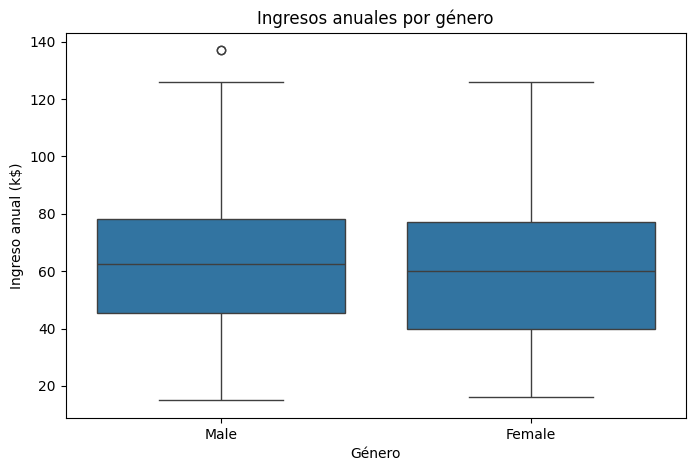

In [5]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Gender', y='Annual Income (k$)', data=df)

plt.title('Ingresos anuales por género')
plt.xlabel('Género')
plt.ylabel('Ingreso anual (k$)')

plt.show()


### 3. ¿Cómo se distribuye la puntuación de gasto (Spending Score) entre los diferentes rangos de edad?
- **Objetivo**: Analizar la relación entre la edad y la puntuación de gasto.
- **Respuesta esperada**: Una gráfica de dispersión (scatter plot) o un gráfico de cajas que compare la Spending Score (1-100) con diferentes grupos de edad.

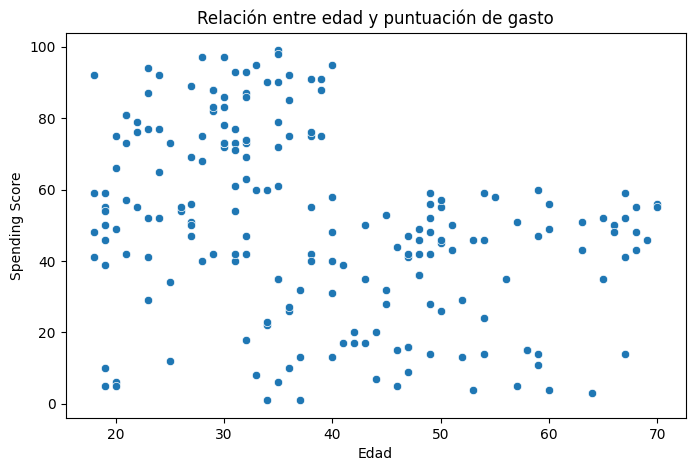

In [6]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Age', y='Spending Score (1-100)', data=df)

plt.title('Relación entre edad y puntuación de gasto')
plt.xlabel('Edad')
plt.ylabel('Spending Score')

plt.show()


### 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?
- **Objetivo**: Identificar si existe una relación lineal entre el ingreso y el gasto.
- **Respuesta esperada**: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

In [7]:
correlacion = df['Annual Income (k$)'].corr(df['Spending Score (1-100)'])
print("La correlación entre ingreso anual y spending score es:", correlacion)


La correlación entre ingreso anual y spending score es: 0.009902848094037651


### 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?
- **Objetivo**: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.
- **Respuesta esperada**: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).

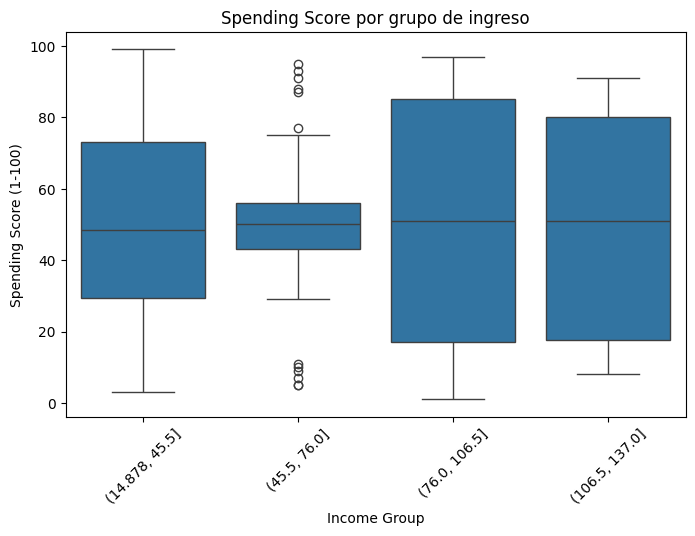

In [8]:
# Crear rangos de ingreso
df['Income Group'] = pd.cut(df['Annual Income (k$)'], bins=4)

plt.figure(figsize=(8,5))
sns.boxplot(x='Income Group', y='Spending Score (1-100)', data=df)

plt.title('Spending Score por grupo de ingreso')
plt.xticks(rotation=45)
plt.show()


### 6. ¿Cuál es la proporción de clientes por género?
- **Objetivo**: Determinar el balance de género en el conjunto de datos.
- **Respuesta esperada**: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

Gender
Female    112
Male       88
Name: count, dtype: int64


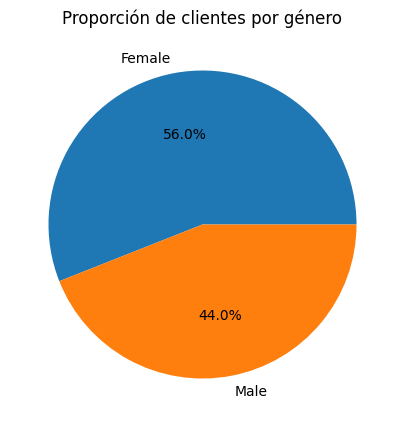

In [9]:
# Conteo por género
gender_counts = df['Gender'].value_counts()
print(gender_counts)

# Gráfica de pastel
plt.figure(figsize=(5,5))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title('Proporción de clientes por género')
plt.show()


### 7. ¿Qué grupos de edad gastan más en promedio?
- **Objetivo**: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio.
- **Respuesta esperada**: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.

In [10]:
# Seleccionar variables para clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


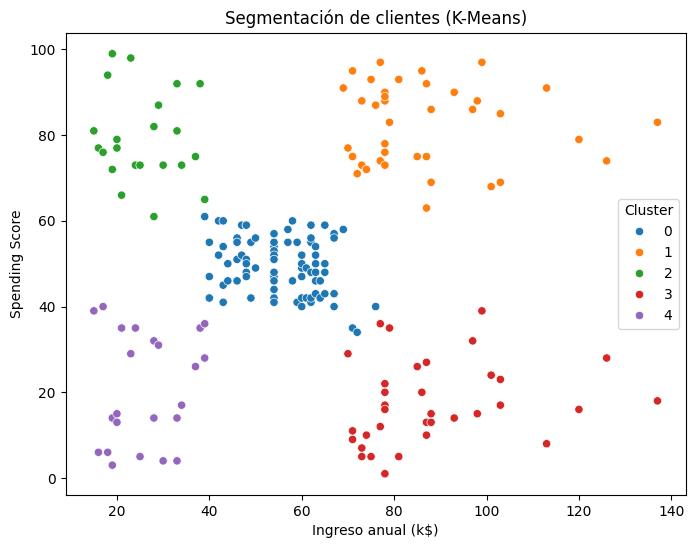

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='tab10',
    data=df
)

plt.title('Segmentación de clientes (K-Means)')
plt.xlabel('Ingreso anual (k$)')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.show()


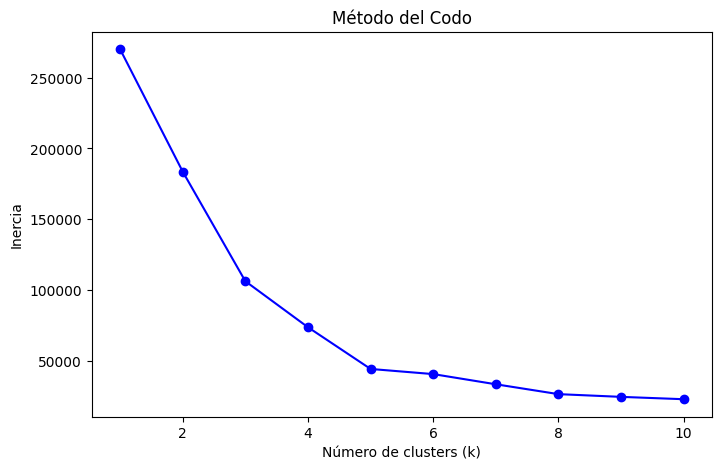

In [11]:
from sklearn.cluster import KMeans

inertia = []

K = range(1,11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()


In [15]:
# Crear modelo final con 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)

# Ajustar modelo
df['Cluster'] = kmeans.fit_predict(X)

df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Group,Cluster
0,1,Male,19,15,39,"(14.878, 45.5]",4
1,2,Male,21,15,81,"(14.878, 45.5]",2
2,3,Female,20,16,6,"(14.878, 45.5]",4
3,4,Female,23,16,77,"(14.878, 45.5]",2
4,5,Female,31,17,40,"(14.878, 45.5]",4


### 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?
- **Objetivo**: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.
- **Respuesta esperada**: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

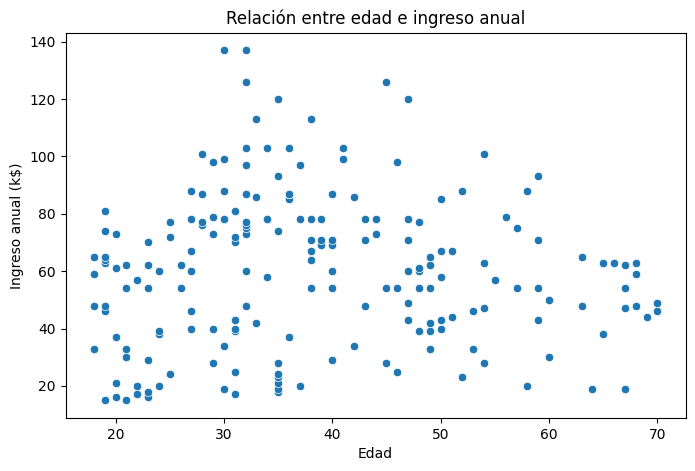

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Annual Income (k$)', data=df)

plt.title('Relación entre edad e ingreso anual')
plt.xlabel('Edad')
plt.ylabel('Ingreso anual (k$)')
plt.show()


### 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?
- **Objetivo**: Entender cómo se distribuyen estas dos variables en conjunto.
- **Respuesta esperada**: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

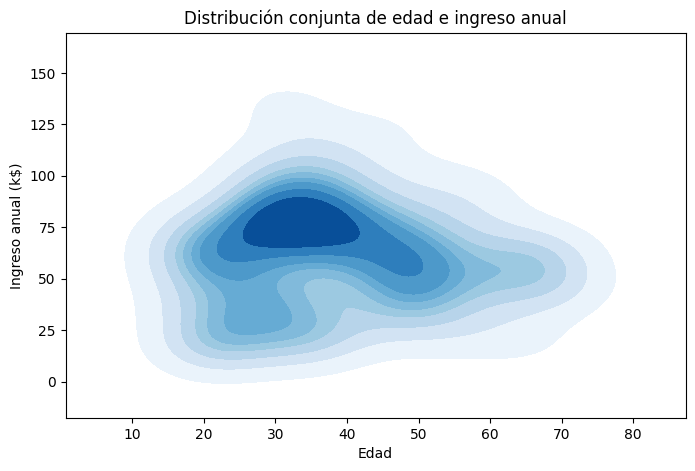

In [17]:
plt.figure(figsize=(8,5))
sns.kdeplot(x='Age', y='Annual Income (k$)', data=df, fill=True, cmap='Blues')

plt.title('Distribución conjunta de edad e ingreso anual')
plt.xlabel('Edad')
plt.ylabel('Ingreso anual (k$)')
plt.show()


### 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?
- **Objetivo**: Analizar la relación entre la puntuación de gasto y el género.
- **Respuesta esperada**: Una gráfica de dispersión o un gráfico de violín que muestre la Spending Score (1-100) separada por género.

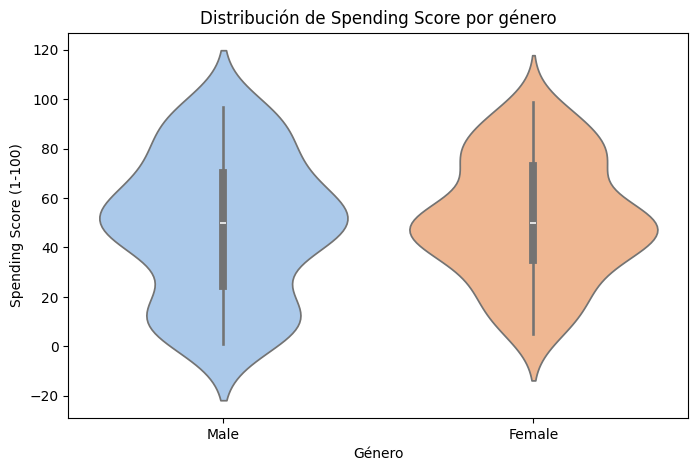

In [19]:
plt.figure(figsize=(8,5))

sns.violinplot(x='Gender', y='Spending Score (1-100)', data=df, palette='pastel')

plt.title('Distribución de Spending Score por género')
plt.xlabel('Género')
plt.ylabel('Spending Score (1-100)')

plt.show()
